## Setup: Import Libraries and Configure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Configuration
MAF_FILE = 'mc3.v0.2.8.PUBLIC.maf'

print(f"[{datetime.now().strftime('%H:%M:%S')}] Environment initialized")
print(f"MAF file: {MAF_FILE}")

[22:57:06] Environment initialized
MAF file: mc3.v0.2.8.PUBLIC.maf


## Step 1: Load MAF File

In [2]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Loading MAF file...")

# Load MAF file
try:
    maf = pd.read_csv(MAF_FILE, sep='\t', low_memory=False, comment='#')
    print(f"✓ MAF loaded successfully")
except Exception as e:
    print(f"Error loading MAF: {e}")
    raise

print(f"\nDataset Info:")
print(f"  Total mutations: {len(maf):,}")
print(f"  Total columns: {len(maf.columns)}")
print(f"  \nColumn names: {list(maf.columns[:15])}...")
print(f"\nFirst few rows:")
print(maf.head(3))

[22:57:16] Loading MAF file...
✓ MAF loaded successfully

Dataset Info:
  Total mutations: 3,600,963
  Total columns: 114
  
Column names: ['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand', 'Variant_Classification', 'Variant_Type', 'Reference_Allele', 'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS', 'dbSNP_Val_Status']...

First few rows:
  Hugo_Symbol  Entrez_Gene_Id Center NCBI_Build Chromosome  Start_Position  \
0       TACC2               0      .     GRCh37         10       123810032   
1     JAKMIP3               0      .     GRCh37         10       133967449   
2       PANX3               0      .     GRCh37         11       124489539   

   End_Position Strand Variant_Classification Variant_Type  ... ExAC_AF_NFE  \
0     123810032      +      Missense_Mutation          SNP  ...           .   
1     133967449      +                 Silent          SNP  ...           .   
2     124489539      +      Missense_Mu

## Step 2: Explore Variant Types and Filter Data

In [3]:
# Check available variant classifications
print(f"Unique Variant Classifications:")
print(f"{maf['Variant_Classification'].value_counts()}")

# Define non-silent (pathogenic) mutations
NON_SILENT = {
    'Missense_Mutation', 'Nonsense_Mutation',
    'Frame_Shift_Del', 'Frame_Shift_Ins',
    'Splice_Site', 'In_Frame_Del', 'In_Frame_Ins',
    'Translation_Start_Site', 'Nonstop_Mutation'
}

print(f"\nFiltering to non-silent mutations only...")
maf_filtered = maf[maf['Variant_Classification'].isin(NON_SILENT)].copy()
print(f"✓ Filtered mutations: {len(maf_filtered):,} ({100*len(maf_filtered)/len(maf):.1f}%)")

Unique Variant Classifications:
Variant_Classification
Missense_Mutation         1921979
Silent                     782687
3'UTR                      282636
Nonsense_Mutation          157232
Intron                     108104
Frame_Shift_Del             87013
5'UTR                       81323
Splice_Site                 50617
RNA                         49540
Frame_Shift_Ins             27128
3'Flank                     21060
5'Flank                     15726
In_Frame_Del                10254
Translation_Start_Site       2723
Nonstop_Mutation             2042
In_Frame_Ins                  899
Name: count, dtype: int64

Filtering to non-silent mutations only...
✓ Filtered mutations: 2,259,887 (62.8%)


## Step 3: Calculate Mutation Frequency Per Gene

In [4]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Calculating mutation frequencies...")

# Extract patient ID (first 12 chars of Tumor_Sample_Barcode for TCGA IDs)
maf_filtered['Patient'] = maf_filtered['Tumor_Sample_Barcode'].str[:12]

# Count total unique patients
total_patients = maf_filtered['Patient'].nunique()
print(f"\nTotal unique patients: {total_patients:,}")

# Calculate frequency per gene
gene_freq = maf_filtered.groupby('Hugo_Symbol').agg({
    'Patient': 'nunique',  # Number of patients with mutation in this gene
    'Variant_Classification': 'count'  # Total mutations of this gene
}).reset_index()

gene_freq.columns = ['Gene', 'Patients_Mutated', 'Total_Mutations']

# Calculate frequency and percentage
gene_freq['Mutation_Frequency'] = gene_freq['Patients_Mutated'] / total_patients
gene_freq['Frequency_Percent'] = gene_freq['Mutation_Frequency'] * 100

# Rank by frequency (highest first = early events)
gene_freq = gene_freq.sort_values('Mutation_Frequency', ascending=False).reset_index(drop=True)
gene_freq['Progression_Rank'] = range(1, len(gene_freq) + 1)

# Reorder columns
gene_freq = gene_freq[['Progression_Rank', 'Gene', 'Patients_Mutated', 'Total_Mutations', 
                       'Mutation_Frequency', 'Frequency_Percent']]

print(f"\nTotal genes analyzed: {len(gene_freq):,}")
print(f"\n🔴 TOP 20 EARLY PROGRESSION GENES (Highest Mutation Frequency):")
print(gene_freq.head(20).to_string(index=False))

[23:00:19] Calculating mutation frequencies...

Total unique patients: 10,208

Total genes analyzed: 19,687

🔴 TOP 20 EARLY PROGRESSION GENES (Highest Mutation Frequency):
 Progression_Rank   Gene  Patients_Mutated  Total_Mutations  Mutation_Frequency  Frequency_Percent
                1   TP53              3858             4469            0.377939          37.793887
                2    TTN              3225            10589            0.315929          31.592868
                3  MUC16              2041             5059            0.199941          19.994122
                4 PIK3CA              1394             1729            0.136560          13.655956
                5  CSMD3              1369             2461            0.134111          13.411050
                6   RYR2              1330             2315            0.130290          13.028997
                7  LRP1B              1310             2389            0.128331          12.833072
                8  SYNE1            

## Step 4: Calculate VAF (Variant Allele Frequency) Metrics

In [5]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Calculating VAF statistics...")

# Check if VAF columns exist, if not skip this step
if 't_alt_count' in maf_filtered.columns and 't_ref_count' in maf_filtered.columns:
    # Convert to numeric
    maf_filtered['t_alt_count'] = pd.to_numeric(maf_filtered['t_alt_count'], errors='coerce')
    maf_filtered['t_ref_count'] = pd.to_numeric(maf_filtered['t_ref_count'], errors='coerce')
    
    # Calculate VAF
    maf_filtered['Total_Depth'] = maf_filtered['t_alt_count'] + maf_filtered['t_ref_count']
    maf_filtered['VAF'] = np.where(
        maf_filtered['Total_Depth'] > 0,
        maf_filtered['t_alt_count'] / maf_filtered['Total_Depth'],
        np.nan
    )
    
    # Calculate VAF stats per gene
    vaf_stats = maf_filtered.dropna(subset=['VAF']).groupby('Hugo_Symbol')['VAF'].agg([
        ('Mean_VAF', 'mean'),
        ('Median_VAF', 'median'),
        ('Std_VAF', 'std')
    ]).reset_index()
    
    # Merge with frequency data
    gene_freq = gene_freq.merge(vaf_stats, left_on='Gene', right_on='Hugo_Symbol', how='left')
    gene_freq = gene_freq.drop('Hugo_Symbol', axis=1)
    
    print(f"✓ VAF statistics calculated for {len(vaf_stats):,} genes")
    print(f"\nTop genes with VAF data:")
    print(gene_freq[gene_freq['Mean_VAF'].notna()].head(10).to_string(index=False))
else:
    print("⚠ VAF columns not available in MAF file, skipping VAF analysis")
    gene_freq['Mean_VAF'] = np.nan
    gene_freq['Median_VAF'] = np.nan

[22:38:42] Calculating VAF statistics...
✓ VAF statistics calculated for 19,687 genes

Top genes with VAF data:
 Progression_Rank   Gene  Patients_Mutated  Total_Mutations  Mutation_Frequency  Frequency_Percent  Mean_VAF  Median_VAF  Std_VAF
                1   TP53              3858             4469            0.377939          37.793887  0.491316    0.464286 0.233759
                2    TTN              3225            10589            0.315929          31.592868  0.277140    0.267606 0.141595
                3  MUC16              2041             5059            0.199941          19.994122  0.283096    0.271605 0.148880
                4 PIK3CA              1394             1729            0.136560          13.655956  0.326891    0.308943 0.167514
                5  CSMD3              1369             2461            0.134111          13.411050  0.262542    0.241379 0.147289
                6   RYR2              1330             2315            0.130290          13.028997  0.275319

## Step 5: Visualize Cancer Progression

✓ Saved: cancer_progression_top25.png


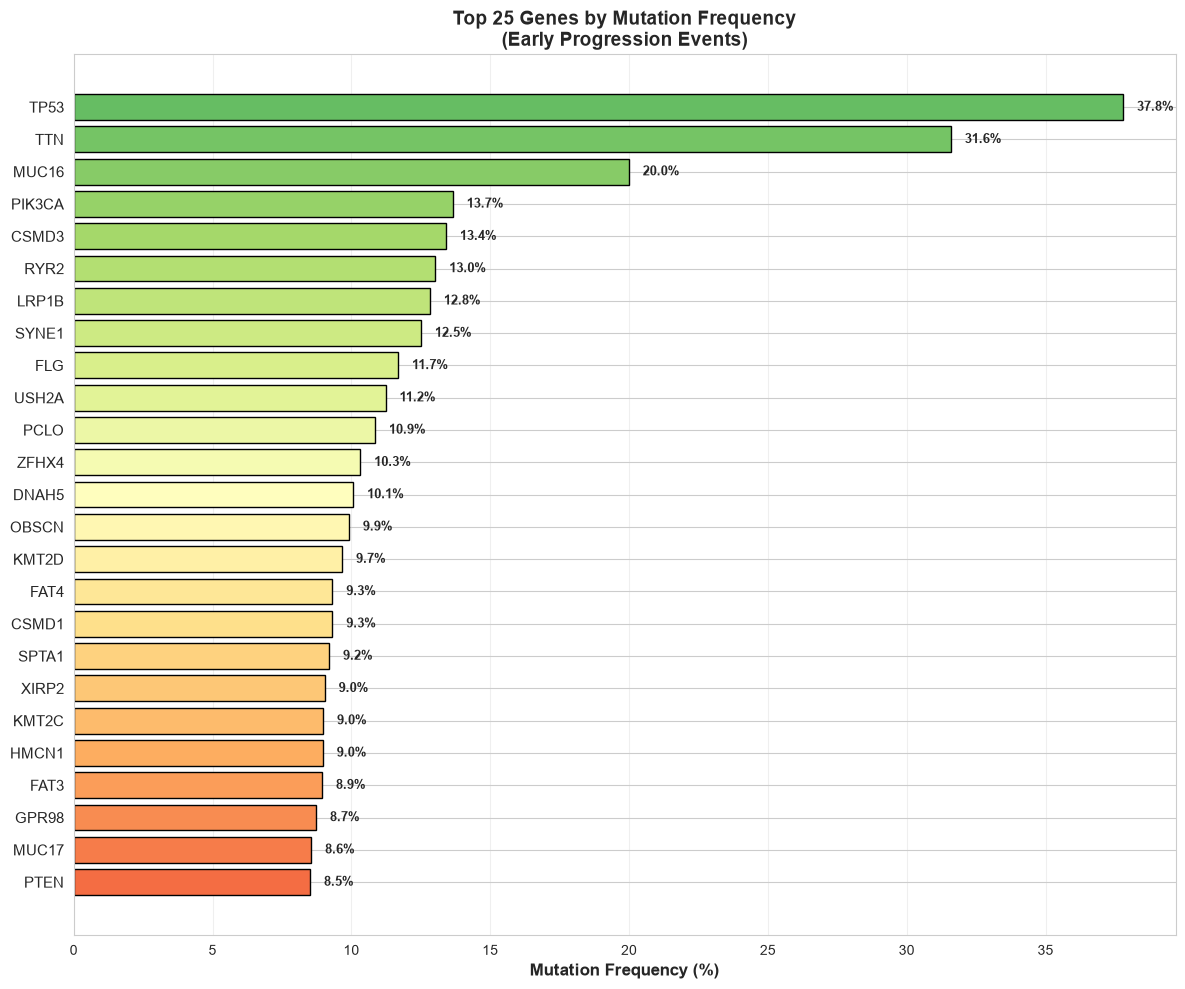

In [6]:
# Plot 1: Top 25 genes by mutation frequency
fig, ax = plt.subplots(figsize=(12, 10))

top_genes = gene_freq.head(25)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_genes)))

bars = ax.barh(range(len(top_genes)), top_genes['Frequency_Percent'].values, color=colors, edgecolor='black')
ax.set_yticks(range(len(top_genes)))
ax.set_yticklabels(top_genes['Gene'].values, fontsize=11)
ax.set_xlabel('Mutation Frequency (%)', fontsize=12, fontweight='bold')
ax.set_title('Top 25 Genes by Mutation Frequency\n(Early Progression Events)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add percentage labels
for i, (gene, pct) in enumerate(zip(top_genes['Gene'].values, top_genes['Frequency_Percent'].values)):
    ax.text(pct + 0.5, i, f"{pct:.1f}%", va='center', fontsize=9, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('cancer_progression_top25.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cancer_progression_top25.png")
plt.show()

✓ Saved: cancer_progression_top50.png


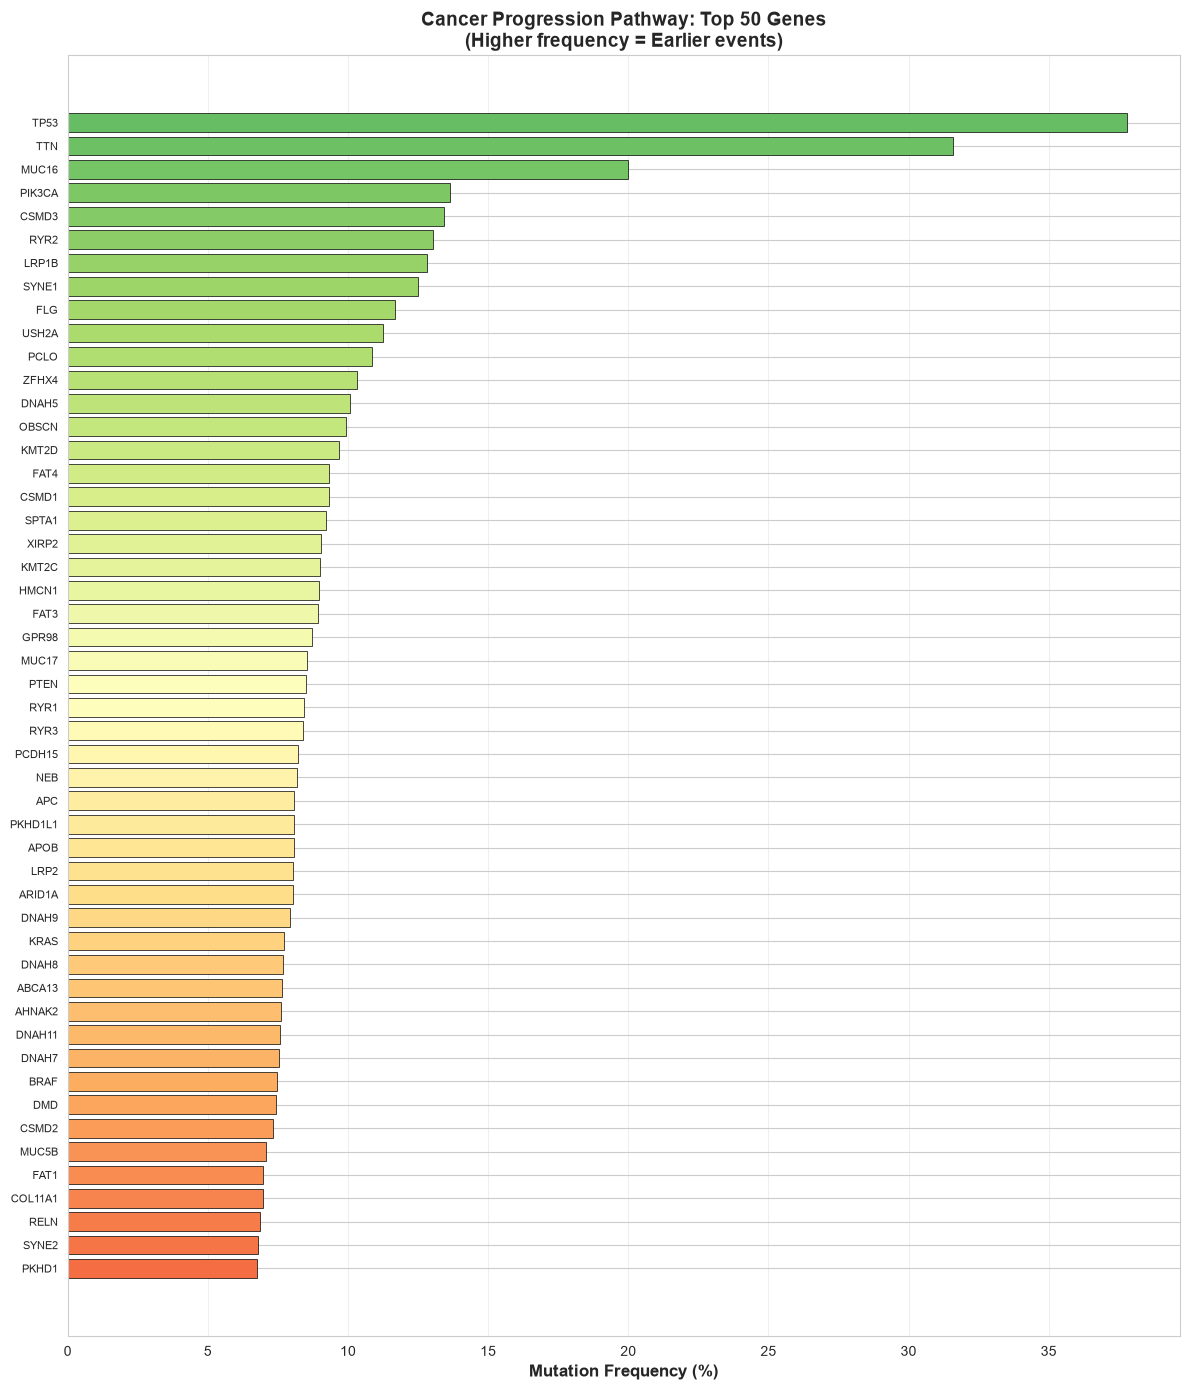

In [7]:
# Plot 2: Top 50 genes
fig, ax = plt.subplots(figsize=(12, 14))

top50_genes = gene_freq.head(50)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top50_genes)))

bars = ax.barh(range(len(top50_genes)), top50_genes['Frequency_Percent'].values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top50_genes)))
ax.set_yticklabels(top50_genes['Gene'].values, fontsize=8)
ax.set_xlabel('Mutation Frequency (%)', fontsize=12, fontweight='bold')
ax.set_title('Cancer Progression Pathway: Top 50 Genes\n(Higher frequency = Earlier events)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cancer_progression_top50.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cancer_progression_top50.png")
plt.show()

✓ Saved: cancer_progression_distributions.png


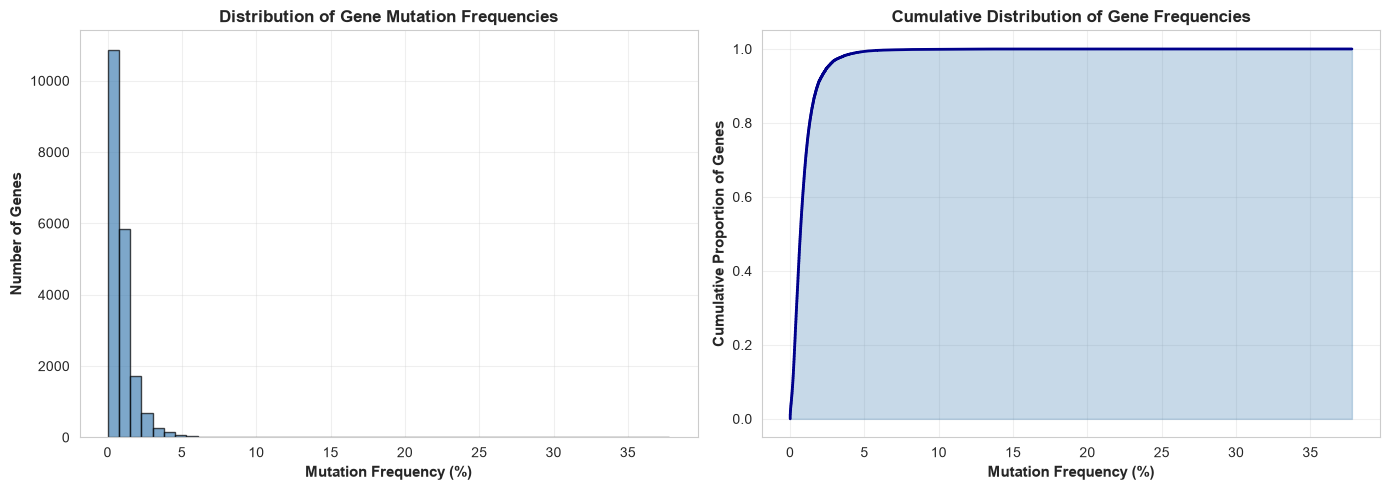

In [8]:
# Plot 3: Frequency distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(gene_freq['Frequency_Percent'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Mutation Frequency (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Genes', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Gene Mutation Frequencies', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# CDF
ax2 = axes[1]
sorted_freq = np.sort(gene_freq['Frequency_Percent'].values)
cdf = np.arange(1, len(sorted_freq) + 1) / len(sorted_freq)
ax2.plot(sorted_freq, cdf, linewidth=2, color='darkblue')
ax2.fill_between(sorted_freq, cdf, alpha=0.3, color='steelblue')
ax2.set_xlabel('Mutation Frequency (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Proportion of Genes', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Distribution of Gene Frequencies', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cancer_progression_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: cancer_progression_distributions.png")
plt.show()

## Step 6: Export Results

In [9]:
print(f"[{datetime.now().strftime('%H:%M:%S')}] Exporting results...")

# Export full results
output_file = 'cancer_progression_results.csv'
gene_freq.to_csv(output_file, index=False)
print(f"✓ Exported: {output_file}")

# Export as TSV for better compatibility
output_tsv = 'cancer_progression_results.tsv'
gene_freq.to_csv(output_tsv, sep='\t', index=False)
print(f"✓ Exported: {output_tsv}")

[22:39:18] Exporting results...
✓ Exported: cancer_progression_results.csv
✓ Exported: cancer_progression_results.tsv


## Step 7: Summary Statistics

In [10]:
print("\n" + "="*80)
print("CANCER PROGRESSION ANALYSIS - SUMMARY")
print("="*80)

print(f"\n📊 DATASET STATISTICS:")
print(f"  Total mutations (all types): {len(maf):,}")
print(f"  Non-silent mutations: {len(maf_filtered):,}")
print(f"  Total unique patients: {total_patients:,}")
print(f"  Total unique genes: {len(gene_freq):,}")

print(f"\n📈 FREQUENCY BREAKDOWN:")
print(f"  Genes with >50% frequency (ultra-frequent): {(gene_freq['Frequency_Percent'] > 50).sum()}")
print(f"  Genes with 20-50% frequency (frequent): {((gene_freq['Frequency_Percent'] >= 20) & (gene_freq['Frequency_Percent'] <= 50)).sum()}")
print(f"  Genes with 5-20% frequency (moderate): {((gene_freq['Frequency_Percent'] >= 5) & (gene_freq['Frequency_Percent'] < 20)).sum()}")
print(f"  Genes with <5% frequency (rare): {(gene_freq['Frequency_Percent'] < 5).sum()}")

print(f"\n🔬 PROGRESSION LOGIC:")
print(f"  Higher frequency genes = EARLY progression events (clonal)")
print(f"  Lower frequency genes = LATE progression events (subclonal)")

print(f"\n🎯 TOP 15 EARLY DRIVER GENES:")
for idx, row in gene_freq.head(15).iterrows():
    print(f"  {row['Progression_Rank']:2d}. {row['Gene']:20s} - {row['Frequency_Percent']:6.2f}% ({int(row['Patients_Mutated']):,} patients)")

print(f"\n" + "="*80)
print(f"✓ Analysis complete. Results exported to:")
print(f"  - cancer_progression_results.csv")
print(f"  - cancer_progression_results.tsv")
print(f"  - cancer_progression_top25.png")
print(f"  - cancer_progression_top50.png")
print(f"  - cancer_progression_distributions.png")
print(f"\n" + "="*80)


CANCER PROGRESSION ANALYSIS - SUMMARY

📊 DATASET STATISTICS:
  Total mutations (all types): 3,600,963
  Non-silent mutations: 2,259,887
  Total unique patients: 10,208
  Total unique genes: 19,687

📈 FREQUENCY BREAKDOWN:
  Genes with >50% frequency (ultra-frequent): 0
  Genes with 20-50% frequency (frequent): 2
  Genes with 5-20% frequency (moderate): 129
  Genes with <5% frequency (rare): 19556

🔬 PROGRESSION LOGIC:
  Higher frequency genes = EARLY progression events (clonal)
  Lower frequency genes = LATE progression events (subclonal)

🎯 TOP 15 EARLY DRIVER GENES:
   1. TP53                 -  37.79% (3,858 patients)
   2. TTN                  -  31.59% (3,225 patients)
   3. MUC16                -  19.99% (2,041 patients)
   4. PIK3CA               -  13.66% (1,394 patients)
   5. CSMD3                -  13.41% (1,369 patients)
   6. RYR2                 -  13.03% (1,330 patients)
   7. LRP1B                -  12.83% (1,310 patients)
   8. SYNE1                -  12.51% (1,277 pat

# Frequency-Based Cancer Progression Analysis

## Overview
This notebook analyzes mutation frequency data from the MAF file to determine cancer progression order.

### Key Logic
- **Higher mutation frequency** → Gene mutated in more patients → **EARLY progression event** (clonal mutations)
- **Lower mutation frequency** → Gene mutated in fewer patients → **LATE progression event** (subclonal mutations)

### Example
If **TP53** is mutated in 60% of patients and a rare **gene X** is mutated in 5% of patients:
- TP53 is an **early driver** (likely present early in tumor evolution)
- Gene X is a **late event** (likely acquired later in specific clones)

## Step 8: Three-Way Concordance Analysis (Frequency vs TRACERx vs DPClust)

Compare cancer progression rankings from 3 methods:
1. **Mutation Frequency** (from MC3 MAF, filtered to NSCLC driver genes)
2. **TRACERx CCF** (99 NSCLC patients, CCF-based progression score)
3. **DPClust CCF** (TCGA NSCLC LUAD+LUSC, ~896 patients, CCF-based progression score)

All filtered to **shared COSMIC NSCLC driver genes**.

In [5]:
from scipy import stats

# === Load COSMIC NSCLC Driver Genes ===
cosmic_drivers = pd.read_csv('cosmic_lung_nsclc_driver_genes (1).tsv', sep='\t')
driver_genes = set(cosmic_drivers['GENE_SYMBOL'].str.strip().unique())
print(f"COSMIC NSCLC driver genes loaded: {len(driver_genes)}")

# === Load TRACERx Progression Data ===
tracerx_path = r'C:\CloneHD_benchmarking\_dpclust_publish\TCGA\outputs_old_nsclc\validation_gene_progression\tracerx_gene_progression_driver_only.tsv'
tracerx_df = pd.read_csv(tracerx_path, sep='\t')
print(f"\nTRACERx progression data: {len(tracerx_df)} genes")
print(f"  Cohort: {tracerx_df['cohort'].iloc[0]}")

# === Load DPClust NSCLC Progression Data ===
dpclust_path = r'C:\CloneHD_benchmarking\_dpclust_publish\TCGA\outputs_old_nsclc\validation_gene_progression\luad_gene_progression_driver_only.tsv'
dpclust_df = pd.read_csv(dpclust_path, sep='\t')
print(f"\nDPClust NSCLC progression data: {len(dpclust_df)} genes")
print(f"  Cohort: {dpclust_df['cohort'].iloc[0]}")

# === Filter Frequency-based results to NSCLC driver genes only ===
freq_drivers = gene_freq[gene_freq['Gene'].isin(driver_genes)].copy()
freq_drivers = freq_drivers.sort_values('Mutation_Frequency', ascending=False).reset_index(drop=True)
freq_drivers['rank_freq'] = range(1, len(freq_drivers) + 1)
print(f"\nFrequency-based (filtered to NSCLC drivers): {len(freq_drivers)} genes")

print(f"\n--- Data Summary ---")
print(f"  TRACERx genes: {len(tracerx_df)}")
print(f"  DPClust genes: {len(dpclust_df)}")
print(f"  Frequency genes (driver-filtered): {len(freq_drivers)}")

COSMIC NSCLC driver genes loaded: 75

TRACERx progression data: 69 genes
  Cohort: TRACERx_NEJM_2017

DPClust NSCLC progression data: 73 genes
  Cohort: TCGA_LUAD_old_dpclust3p_v100_raw

Frequency-based (filtered to NSCLC drivers): 74 genes

--- Data Summary ---
  TRACERx genes: 69
  DPClust genes: 73
  Frequency genes (driver-filtered): 74


In [6]:
# === Merge all 3 datasets on shared genes ===

# Prepare each dataset with consistent column names
tracerx_merge = tracerx_df[['gene', 'rank_progression', 'progression_score', 'prevalence', 'median_ccf']].copy()
tracerx_merge.columns = ['gene', 'rank_tracerx', 'score_tracerx', 'prevalence_tracerx', 'median_ccf_tracerx']

dpclust_merge = dpclust_df[['gene', 'rank_progression', 'progression_score', 'prevalence', 'median_ccf']].copy()
dpclust_merge.columns = ['gene', 'rank_dpclust', 'score_dpclust', 'prevalence_dpclust', 'median_ccf_dpclust']

freq_merge = freq_drivers[['Gene', 'rank_freq', 'Mutation_Frequency', 'Frequency_Percent']].copy()
freq_merge.columns = ['gene', 'rank_freq', 'freq_score', 'freq_percent']

# Merge all three
merged = tracerx_merge.merge(dpclust_merge, on='gene', how='inner')
merged = merged.merge(freq_merge, on='gene', how='inner')

# Sort by average rank across all 3 methods
merged['avg_rank'] = (merged['rank_tracerx'] + merged['rank_dpclust'] + merged['rank_freq']) / 3
merged = merged.sort_values('avg_rank').reset_index(drop=True)

print(f"=== SHARED GENES ACROSS ALL 3 METHODS: {len(merged)} ===\n")
print(merged[['gene', 'rank_tracerx', 'rank_dpclust', 'rank_freq', 'avg_rank']].to_string(index=False))

=== SHARED GENES ACROSS ALL 3 METHODS: 68 ===

    gene  rank_tracerx  rank_dpclust  rank_freq  avg_rank
    TP53             2             1          1  1.333333
   CSMD3             1             2          2  1.666667
    KRAS             3             4          3  3.333333
   PTPRD             7             7          7  7.000000
   PTPRT             5            12          6  7.666667
    ASPM             8             9          8  8.333333
   BIRC6            12            10          5  9.000000
   ERBB4            10            13         11 11.333333
    EGFR             4            18         15 12.333333
    ROS1             6            23         10 13.000000
  NOTCH1            15            16         13 14.666667
     HGF            11             8         26 15.000000
   KEAP1            20             5         22 15.666667
  NFE2L2            14            11         24 16.333333
     ALK             9            25         19 17.666667
  GRIN2A            26   

In [7]:
# === Calculate Concordance Index (Harrell's C-index) ===
def calculate_concordance(rank1, rank2):
    """Calculate concordance index between two ranking vectors."""
    n = len(rank1)
    concordant = 0
    discordant = 0
    tied = 0
    
    for i in range(n - 1):
        for j in range(i + 1, n):
            diff1 = np.sign(rank1[i] - rank1[j])
            diff2 = np.sign(rank2[i] - rank2[j])
            
            if diff1 == diff2 and diff1 != 0:
                concordant += 1
            elif diff1 != diff2 and diff1 != 0 and diff2 != 0:
                discordant += 1
            else:
                tied += 1
    
    total = concordant + discordant
    c_index = concordant / total if total > 0 else 0
    return c_index, concordant, discordant, tied

# === Compute all metrics for 3 pairs ===
pairs = [
    ('Frequency vs TRACERx', merged['rank_freq'].values, merged['rank_tracerx'].values),
    ('Frequency vs DPClust', merged['rank_freq'].values, merged['rank_dpclust'].values),
    ('TRACERx vs DPClust', merged['rank_tracerx'].values, merged['rank_dpclust'].values),
]

print("="*80)
print("CONCORDANCE ANALYSIS - THREE-WAY COMPARISON")
print(f"Shared genes: {len(merged)}")
print("="*80)

results = []
for name, r1, r2 in pairs:
    # Spearman correlation
    spearman_rho, spearman_p = stats.spearmanr(r1, r2)
    # Kendall tau
    kendall_tau, kendall_p = stats.kendalltau(r1, r2)
    # Concordance index
    c_index, conc, disc, tied = calculate_concordance(r1, r2)
    
    results.append({
        'Comparison': name,
        'Spearman_rho': spearman_rho,
        'Spearman_p': spearman_p,
        'Kendall_tau': kendall_tau,
        'Kendall_p': kendall_p,
        'C_index': c_index,
        'Concordant_pairs': conc,
        'Discordant_pairs': disc,
    })
    
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(f"  Spearman ρ:       {spearman_rho:.4f}  (p = {spearman_p:.2e})")
    print(f"  Kendall τ:        {kendall_tau:.4f}  (p = {kendall_p:.2e})")
    print(f"  Concordance Index: {c_index:.4f}  ({c_index*100:.1f}%)")
    print(f"  Concordant pairs:  {conc}")
    print(f"  Discordant pairs:  {disc}")

print(f"\n{'='*80}")

# Store as DataFrame for export
concordance_df = pd.DataFrame(results)
print("\nSummary Table:")
print(concordance_df[['Comparison', 'Spearman_rho', 'Kendall_tau', 'C_index']].to_string(index=False))

CONCORDANCE ANALYSIS - THREE-WAY COMPARISON
Shared genes: 68

────────────────────────────────────────────────────────────
  Frequency vs TRACERx
────────────────────────────────────────────────────────────
  Spearman ρ:       0.7642  (p = 3.39e-14)
  Kendall τ:        0.5733  (p = 4.74e-12)
  Concordance Index: 0.7867  (78.7%)
  Concordant pairs:  1792
  Discordant pairs:  486

────────────────────────────────────────────────────────────
  Frequency vs DPClust
────────────────────────────────────────────────────────────
  Spearman ρ:       0.7060  (p = 1.76e-11)
  Kendall τ:        0.5637  (p = 1.07e-11)
  Concordance Index: 0.7818  (78.2%)
  Concordant pairs:  1781
  Discordant pairs:  497

────────────────────────────────────────────────────────────
  TRACERx vs DPClust
────────────────────────────────────────────────────────────
  Spearman ρ:       0.7550  (p = 1.03e-13)
  Kendall τ:        0.5654  (p = 9.24e-12)
  Concordance Index: 0.7827  (78.3%)
  Concordant pairs:  1783
  Disc

✓ Saved: concordance_rank_comparison.png


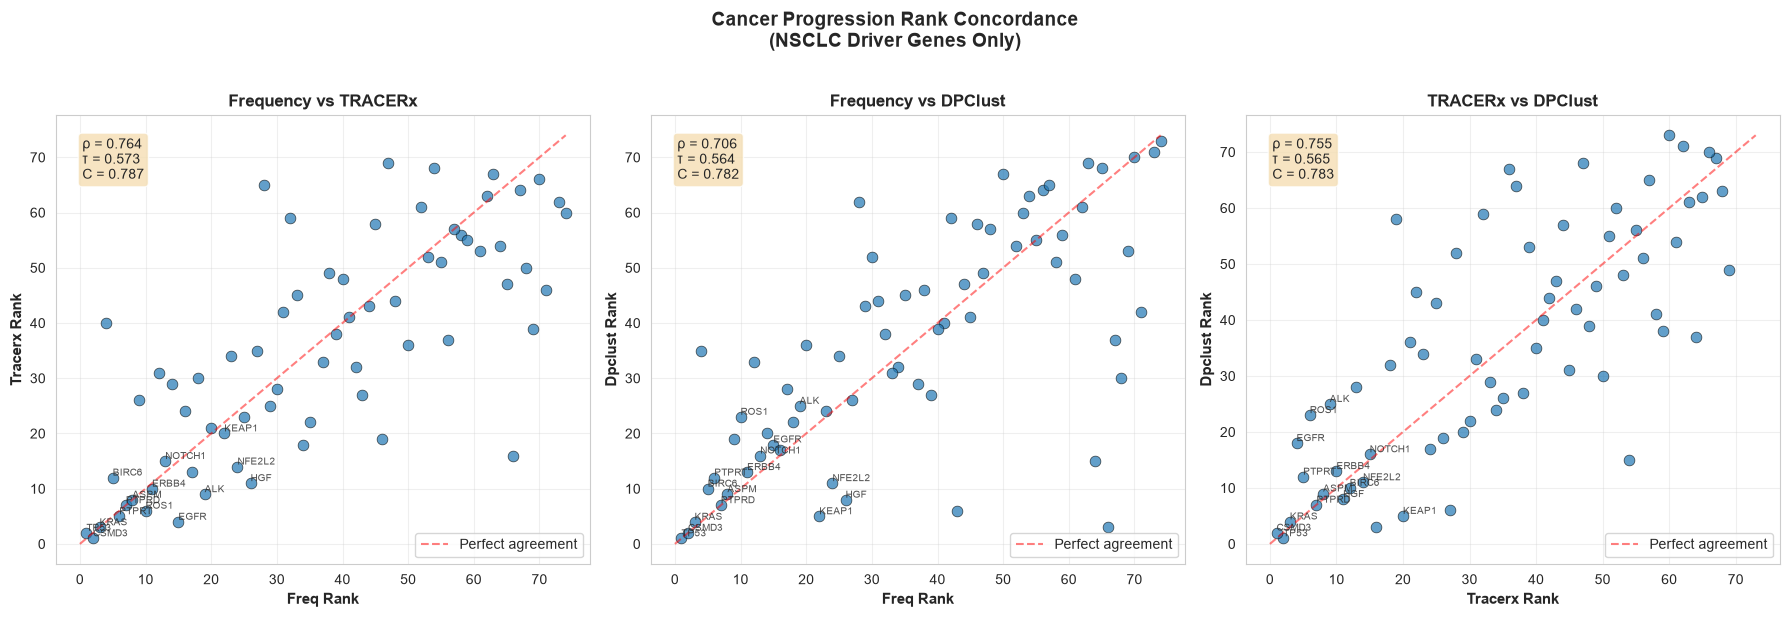

In [8]:
# === Visualization: Rank Comparison Scatter Plots ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_pairs = [
    (axes[0], 'rank_freq', 'rank_tracerx', 'Frequency vs TRACERx', results[0]),
    (axes[1], 'rank_freq', 'rank_dpclust', 'Frequency vs DPClust', results[1]),
    (axes[2], 'rank_tracerx', 'rank_dpclust', 'TRACERx vs DPClust', results[2]),
]

for ax, col_x, col_y, title, res in plot_pairs:
    ax.scatter(merged[col_x], merged[col_y], s=60, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Add gene labels for top genes
    for _, row in merged.head(15).iterrows():
        ax.annotate(row['gene'], (row[col_x], row[col_y]), fontsize=7, 
                   ha='left', va='bottom', alpha=0.8)
    
    # Add diagonal reference line
    max_val = max(merged[col_x].max(), merged[col_y].max())
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect agreement')
    
    # Add correlation text
    ax.text(0.05, 0.95, f"ρ = {res['Spearman_rho']:.3f}\nτ = {res['Kendall_tau']:.3f}\nC = {res['C_index']:.3f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xlabel(col_x.replace('rank_', '').capitalize() + ' Rank', fontsize=11, fontweight='bold')
    ax.set_ylabel(col_y.replace('rank_', '').capitalize() + ' Rank', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('Cancer Progression Rank Concordance\n(NSCLC Driver Genes Only)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('concordance_rank_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: concordance_rank_comparison.png")
plt.show()

✓ Saved: concordance_heatmaps.png


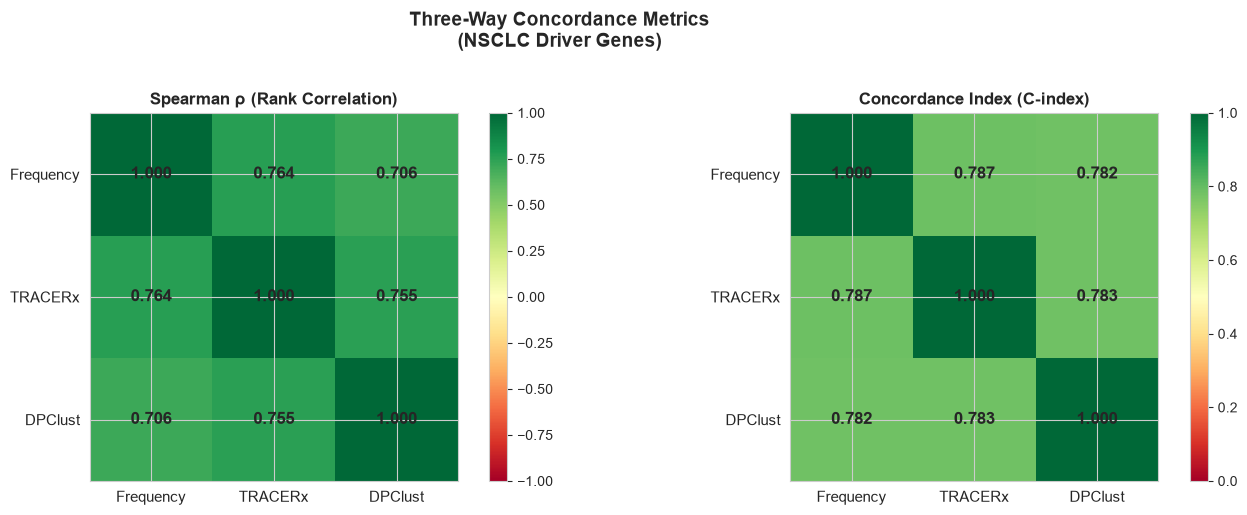

In [9]:
# === Visualization: Heatmap of Concordance Metrics ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spearman correlation matrix
methods = ['Frequency', 'TRACERx', 'DPClust']
spearman_matrix = np.ones((3, 3))
spearman_matrix[0, 1] = spearman_matrix[1, 0] = results[0]['Spearman_rho']
spearman_matrix[0, 2] = spearman_matrix[2, 0] = results[1]['Spearman_rho']
spearman_matrix[1, 2] = spearman_matrix[2, 1] = results[2]['Spearman_rho']

ax1 = axes[0]
im1 = ax1.imshow(spearman_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_xticks(range(3))
ax1.set_yticks(range(3))
ax1.set_xticklabels(methods, fontsize=11)
ax1.set_yticklabels(methods, fontsize=11)
ax1.set_title("Spearman ρ (Rank Correlation)", fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax1.text(j, i, f"{spearman_matrix[i,j]:.3f}", ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, fraction=0.046)

# Concordance Index matrix
c_index_matrix = np.ones((3, 3))
c_index_matrix[0, 1] = c_index_matrix[1, 0] = results[0]['C_index']
c_index_matrix[0, 2] = c_index_matrix[2, 0] = results[1]['C_index']
c_index_matrix[1, 2] = c_index_matrix[2, 1] = results[2]['C_index']

ax2 = axes[1]
im2 = ax2.imshow(c_index_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
ax2.set_xticklabels(methods, fontsize=11)
ax2.set_yticklabels(methods, fontsize=11)
ax2.set_title("Concordance Index (C-index)", fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax2.text(j, i, f"{c_index_matrix[i,j]:.3f}", ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, fraction=0.046)

plt.suptitle('Three-Way Concordance Metrics\n(NSCLC Driver Genes)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('concordance_heatmaps.png', dpi=300, bbox_inches='tight')
print("✓ Saved: concordance_heatmaps.png")
plt.show()

✓ Saved: concordance_bump_chart.png


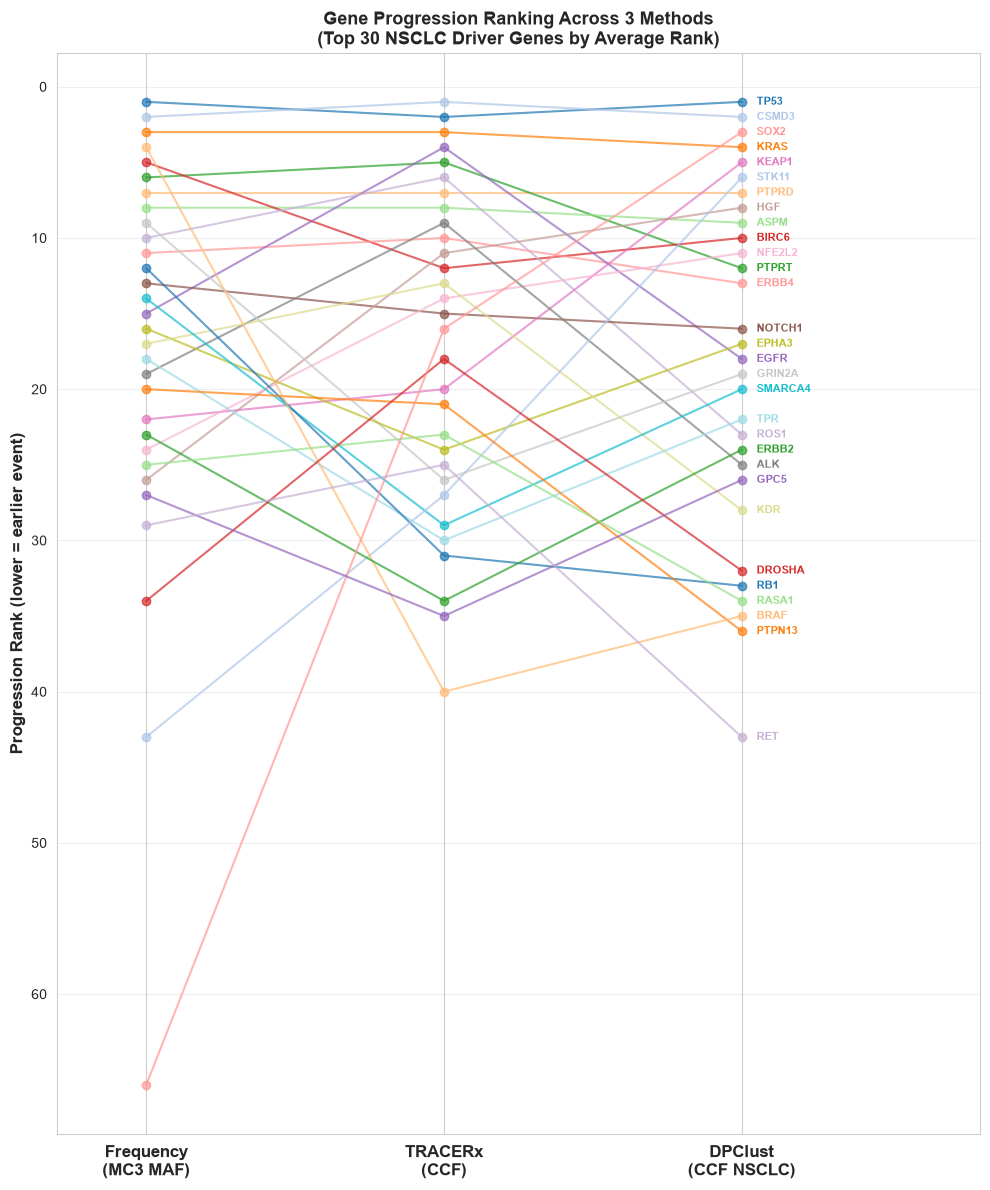

In [10]:
# === Visualization: Bump Chart - Gene Rank Comparison ===
fig, ax = plt.subplots(figsize=(10, 12))

top_n = min(30, len(merged))
top_merged = merged.head(top_n)

x_positions = [0, 1, 2]
x_labels = ['Frequency\n(MC3 MAF)', 'TRACERx\n(CCF)', 'DPClust\n(CCF NSCLC)']

for idx, row in top_merged.iterrows():
    ranks = [row['rank_freq'], row['rank_tracerx'], row['rank_dpclust']]
    color = plt.cm.tab20(idx % 20)
    ax.plot(x_positions, ranks, '-o', color=color, linewidth=1.5, markersize=6, alpha=0.7)
    # Label on right side
    ax.text(2.05, ranks[2], row['gene'], fontsize=8, va='center', color=color, fontweight='bold')

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=12, fontweight='bold')
ax.set_ylabel('Progression Rank (lower = earlier event)', fontsize=12, fontweight='bold')
ax.set_title(f'Gene Progression Ranking Across 3 Methods\n(Top {top_n} NSCLC Driver Genes by Average Rank)', 
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.3)
ax.set_xlim(-0.3, 2.8)

plt.tight_layout()
plt.savefig('concordance_bump_chart.png', dpi=300, bbox_inches='tight')
print("✓ Saved: concordance_bump_chart.png")
plt.show()

In [11]:
# === Export Final Concordance Results ===
print("="*80)
print("FINAL CONCORDANCE ANALYSIS SUMMARY")
print("="*80)

# Export merged comparison table
merged.to_csv('three_way_progression_comparison.tsv', sep='\t', index=False)
print(f"✓ Exported: three_way_progression_comparison.tsv")

# Export concordance metrics
concordance_df.to_csv('concordance_metrics.tsv', sep='\t', index=False)
print(f"✓ Exported: concordance_metrics.tsv")

print(f"\n📊 CONCORDANCE METRICS SUMMARY:")
print(f"{'─'*60}")
print(f"{'Comparison':<25} {'Spearman ρ':>12} {'Kendall τ':>12} {'C-index':>10}")
print(f"{'─'*60}")
for r in results:
    print(f"{r['Comparison']:<25} {r['Spearman_rho']:>12.4f} {r['Kendall_tau']:>12.4f} {r['C_index']:>10.4f}")
print(f"{'─'*60}")

print(f"\n📋 INTERPRETATION:")
print(f"  • C-index > 0.7: Strong concordance (methods agree well)")
print(f"  • C-index 0.5-0.7: Moderate concordance")
print(f"  • C-index < 0.5: Poor concordance (no better than random)")
print(f"\n  • Spearman ρ > 0.6: Strong rank correlation")
print(f"  • Spearman ρ 0.3-0.6: Moderate correlation")
print(f"  • Spearman ρ < 0.3: Weak correlation")

print(f"\n🔬 SHARED GENES ANALYZED: {len(merged)}")
print(f"  Methods compared:")
print(f"    1. Mutation Frequency (MC3 pan-cancer MAF → NSCLC drivers)")
print(f"    2. TRACERx CCF (99 NSCLC patients, multi-region WES)")
print(f"    3. DPClust CCF (TCGA NSCLC: LUAD+LUSC, ~896 patients)")
print(f"\n{'='*80}")

FINAL CONCORDANCE ANALYSIS SUMMARY
✓ Exported: three_way_progression_comparison.tsv
✓ Exported: concordance_metrics.tsv

📊 CONCORDANCE METRICS SUMMARY:
────────────────────────────────────────────────────────────
Comparison                  Spearman ρ    Kendall τ    C-index
────────────────────────────────────────────────────────────
Frequency vs TRACERx            0.7642       0.5733     0.7867
Frequency vs DPClust            0.7060       0.5637     0.7818
TRACERx vs DPClust              0.7550       0.5654     0.7827
────────────────────────────────────────────────────────────

📋 INTERPRETATION:
  • C-index > 0.7: Strong concordance (methods agree well)
  • C-index 0.5-0.7: Moderate concordance
  • C-index < 0.5: Poor concordance (no better than random)

  • Spearman ρ > 0.6: Strong rank correlation
  • Spearman ρ 0.3-0.6: Moderate correlation
  • Spearman ρ < 0.3: Weak correlation

🔬 SHARED GENES ANALYZED: 68
  Methods compared:
    1. Mutation Frequency (MC3 pan-cancer MAF → NSCLC